# eBPF Bottleneck Classifier v8 — Unsupervised Learning, Binary High-Severity Detection

**Built on the v7 champion:** binary framing (High vs. Not-High, `avg_stall_ns >= 1.5ms`), SMOTE + Random Forest,
tuned to High-class F1. v7 is *supervised* — it needs labels at train time.

**v8 asks a different question: can we find the High-severity rows without ever showing the label to the model
during fitting?** This matters if you ever collect a session where you *don't* have (or trust) the stall-based
label, or if you want an independent signal that isn't derived from the same `avg_stall_ns` column the label
itself is built from.

**What "unsupervised but binary" means here, concretely:**
- Section 1 (data loading, cleaning, feature engineering, leakage-free `FEATURE_COLS` allowlist) is carried over
  **unchanged** from v6/v7 — same reference for which columns are safe to use and how they're derived.
- `y` (High vs. Not-High) is still computed the same way as v7, from the same frozen `HIGH_THRESHOLD_NS`. It is
  **never passed to `.fit()` on any model in this notebook.** It exists only so we can *score* each unsupervised
  method afterward and pick a champion — exactly the way you'd validate a real anomaly-detection deployment where
  labels are hard to get in production but exist in a labeled validation slice.
- One exception, flagged explicitly where it happens: a couple of anomaly-detection methods (Isolation Forest,
  One-Class SVM, LOF) take a `contamination`/`nu` hyperparameter — the *expected proportion* of anomalies. We set
  that from the training set's label prevalence, because in practice you'd set it from domain knowledge ("we
  expect ~3% of samples to be bottlenecked") rather than a per-row label. That's a summary statistic, not
  per-example supervision — but it's still label-derived, so it's called out at each use.

**Seven methods, two families:**

| Family | Method | Fit uses | Predict on unseen rows |
|---|---|---|---|
| Partition clustering | KMeans (k=2) | `X_train` only | yes (`.predict`) |
| Partition clustering | Gaussian Mixture (2 components) | `X_train` only | yes (`.predict`) |
| Partition clustering | Agglomerative (Ward, k=2) | test rows directly (no `.predict`) | transductive only |
| Density clustering | DBSCAN | test rows directly (no `.predict`) | transductive only |
| Anomaly / novelty | Isolation Forest | `X_train` only | yes (`.predict`) |
| Anomaly / novelty | One-Class SVM | `X_train`, **Not-High rows only** | yes (`.predict`) |
| Anomaly / novelty | Local Outlier Factor (`novelty=True`) | `X_train`, **Not-High rows only** | yes (`.predict`) |

Since cluster IDs from partition methods are arbitrary (cluster `0` might be High or might be Not-High), each
clustering method is scored under **both** label mappings and the better-aligned one is kept — this is standard
practice for validating unsupervised output against a label you held out for evaluation, not something that
leaks the label into fitting.

| Section | Content |
|---|---|
| 1 | Rebuild the leakage-free feature set (unchanged from v6/v7) |
| 2 | Binary label derivation — **evaluation-only**, never fit on |
| 3 | Stratified train/test split (frozen) + scaling (fit on train only) |
| 4 | Partition clustering: KMeans, Gaussian Mixture |
| 5 | Transductive clustering on the test set: Agglomerative, DBSCAN |
| 6 | Anomaly/novelty detection: Isolation Forest, One-Class SVM, LOF |
| 7 | Comparison table, PR/ROC curves where a continuous score exists |
| 8 | Visual inspection: PCA projection, confusion matrices for the top methods |
| 9 | Champion selection & artifact saving |

**A note on execution:** this notebook was authored without access to `perf_metrics1.csv` / `perf_metrics2.csv`
(they live in your environment, not this one), so it has **not been run** — no cell outputs are baked in. Run it
top to bottom in your own environment. It expects the same CSVs as v6/v7; nothing else needs to be in memory
first.

---
# Section 1 — Load & Rebuild the Leakage-Free Feature Set

Unchanged from v6/v7. If you already have `df` with `FEATURE_COLS` in memory from a v7 run in the same session,
you can skip straight to Section 2 — just confirm `HIGH_THRESHOLD_NS` below still matches.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_recall_fscore_support, f1_score, accuracy_score,
    precision_recall_curve, average_precision_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score
)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RANDOM_STATE = 42

In [2]:
# -- Load multiple CSV parts (manually named, no auto-discovery) --------------
CSV_PARTS = [
    'perf_metrics1.csv',
    'perf_metrics2.csv',
    # add more here as you collect them
]
# -------------------------------------------------------------------------------

dfs = []
for path in CSV_PARTS:
    if not os.path.exists(path):
        print(f"  skipping (not found): {path}")
        continue
    part = pd.read_csv(path)
    part['source_file'] = path
    dfs.append(part)
    print(f"  loaded {path:<20}: {len(part):>8} rows")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df_raw.shape}")
print(f"Sessions found : {df_raw['session_label'].unique().tolist()}")
df_raw['session_label'].value_counts()

  loaded perf_metrics1.csv   :   526895 rows
  loaded perf_metrics2.csv   :   250683 rows

Combined shape: (777578, 45)
Sessions found : ['idle', 'cpu_low', 'cpu_medium', 'cpu_high', 'cpu_overloaded', 'mem_low', 'mem_high', 'io_low', 'lock_low', 'mixed_load', 'cpu_extreme', 'cpu_ultra', 'mem_extreme', 'mem_thrashing', 'cpu_mem_extreme', 'cpu_mem_ultra', 'io_extreme', 'cpu_io_extreme', 'lock_extreme', 'lock_cpu_mix', 'everything_max', 'everything_insane', 'cpu_2x', 'cpu_4x', 'cpu_8x', 'mem_reclaim', 'mem_heavy_reclaim', 'cpu_mem_2x', 'cpu_mem_4x', 'cpu_mem_8x', 'cpu_mem_io', 'cpu_mem_io_heavy', 'lock_heavy', 'lock_cpu_heavy', 'everything_extreme', 'compile_only', 'compile_sysbench', 'compile_blender', 'full_system', 'mem_swap_thrashing', 'cpu_l3_cache_misses', 'mem_swap_thrash', 'mem_tlb_cache_miss', 'io_async_saturation', 'ctx_flood', 'llm_inference', 'ml_training', 'stream_memory_contention', 'cache_contention', 'context_switch_contention']


session_label
stream_memory_contention     146855
cache_contention             133428
context_switch_contention    121529
llm_inference                 39621
everything_max                21993
ml_training                   21422
everything_insane             20568
lock_cpu_heavy                11752
cpu_8x                        10213
lock_low                      10112
lock_heavy                     9933
everything_extreme             9705
cpu_mem_io                     9449
cpu_medium                     9261
full_system                    8964
cpu_low                        8331
cpu_mem_io_heavy               8082
cpu_mem_4x                     8024
cpu_mem_8x                     7969
mem_low                        7914
mem_extreme                    7764
mem_reclaim                    7449
compile_only                   6823
cpu_mem_2x                     6718
io_low                         6653
compile_sysbench               6585
compile_blender                6570
mem_tlb_cache_

In [3]:
# -- CLEANING (same rules as v6/v7) --------------------------------------------
df = df_raw.copy()
before = len(df)

df = df[df['pid'] > 0]
df = df[df['ctx_switches'] > 0]
df = df[df['latency_count'] > 0]

print(f"Cleaned: {before} -> {len(df)} rows ({before - len(df)} removed)")

Cleaned: 777578 -> 664256 rows (113322 removed)


In [4]:
# -- FEATURE ENGINEERING (causal signals only -- same as v6/v7) ---------------
df['involuntary_ratio']  = df['involuntary_switches'] / df['ctx_switches'].clip(lower=1)
df['voluntary_ratio']    = df['voluntary_switches']   / df['ctx_switches'].clip(lower=1)
df['runtime_per_switch'] = df['total_runtime_ns']     / df['ctx_switches'].clip(lower=1)
df['read_write_ratio']   = df['read_bytes'] / (df['write_bytes'] + 1)
df['io_bytes_total']     = df['read_bytes'] + df['write_bytes']
df['alloc_pressure']     = df['total_alloc_bytes'] / df['ctx_switches'].clip(lower=1)
df['lock_pressure']      = (
    df['mutex_contentions'] + df['rwsem_read_contentions'] + df['rwsem_write_contentions']
)

log_cols = ['total_runtime_ns', 'avg_syscall_latency_ns', 'max_syscall_latency_ns',
            'io_bytes_total', 'total_alloc_bytes']
for col in log_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

print(f"Features after engineering: {df.shape[1]} columns")

Features after engineering: 57 columns


In [5]:
# -- EXPLICIT ALLOWLIST (no data leakage) -- identical to v6/v7 --------------
LEAKY_COLS = {
    'avg_stall_ns', 'stall_ns', 'max_stall_ns', 'latency_count',
    'stall_per_switch', 'log_stall_ns', 'log_avg_stall_ns', 'log_max_stall_ns',
    'stall_spike', 'log_stall_spike',
}

ALLOWED_FEATURES = [
    'ctx_switches', 'cpu_migrations', 'involuntary_switches', 'voluntary_switches',
    'involuntary_ratio', 'voluntary_ratio', 'avg_runq_ratio', 'runtime_per_switch',
    'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count',
    'total_alloc_bytes', 'alloc_pressure',
    'read_count', 'write_count', 'read_bytes', 'write_bytes', 'read_write_ratio', 'io_bytes_total',
    'mutex_contentions', 'avg_mutex_wait_ns', 'rwsem_read_contentions', 'rwsem_write_contentions', 'lock_pressure',
    'syscall_count', 'avg_syscall_latency_ns', 'futex_count',
    'log_total_runtime_ns', 'log_avg_syscall_latency_ns', 'log_max_syscall_latency_ns',
    'log_io_bytes_total', 'log_total_alloc_bytes',
]

FEATURE_COLS = [f for f in ALLOWED_FEATURES if f in df.columns]

leakage_check = set(FEATURE_COLS) & LEAKY_COLS
assert len(leakage_check) == 0, f"LEAKAGE DETECTED: {leakage_check}"
print(f"Leakage check passed -- {len(FEATURE_COLS)} features, none target-derived")

Leakage check passed -- 33 features, none target-derived


---
# Section 2 — Binary Label Derivation *(evaluation-only)*

Same fixed threshold as the v7 champion, carried over so the two notebooks stay comparable. **This label is used
below only to score cluster/anomaly output after the fact — no `.fit()` call in this notebook receives `y`.**
If you re-ran v7's TEST CELL 1 and landed on a different `HIGH_THRESHOLD_NS`, update it here to match.

In [6]:
HIGH_THRESHOLD_NS = 1_500_000   # 1.5 ms -- carried over from the v7 champion

df['y'] = (df['avg_stall_ns'] >= HIGH_THRESHOLD_NS).astype(int)
class_names_map = {0: 'Not-High', 1: 'High'}
TARGET_NAMES  = ['Not-High', 'High']
TARGET_LABELS = [0, 1]

print(f"Fixed threshold (ns): High >= {HIGH_THRESHOLD_NS:,}\n")
for cls in TARGET_LABELS:
    count = (df['y'] == cls).sum()
    pct = 100 * count / len(df)
    print(f"  Class {cls} ({class_names_map[cls]:<9}): {count:7d} rows  ({pct:5.1f}%)")

print("\nThis prevalence (~% High) is the only thing borrowed from the label for contamination/nu")
print("hyperparameters in Section 6 -- a summary statistic, not per-row supervision.")

Fixed threshold (ns): High >= 1,500,000

  Class 0 (Not-High ):  635452 rows  ( 95.7%)
  Class 1 (High     ):   28804 rows  (  4.3%)

This prevalence (~% High) is the only thing borrowed from the label for contamination/nu
hyperparameters in Section 6 -- a summary statistic, not per-row supervision.


---
# Section 3 — Stratified Train/Test Split (Frozen) + Scaling

Same split discipline as v6/v7: frozen, stratified on `y` so both classes are represented proportionally in
train and test (stratifying here is just good evaluation practice — it does not feed `y` into any model fit).

Unlike Random Forest, every method in this notebook is distance- or density-based, so **feature scaling matters
a lot** here. `StandardScaler` is fit on `X_train` only and applied to `X_test` — same no-leakage rule as v6/v7's
resamplers.

In [7]:
X = df[FEATURE_COLS].fillna(0)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

test_context = df.loc[X_test.index, ['comm', 'session_label', 'avg_stall_ns', 'max_stall_ns']]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows (frozen)\n")
print("Class distribution -- Train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1).to_string())
print("\nClass distribution -- Test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

HIGH_PREVALENCE_TRAIN = y_train.mean()
print(f"\nHigh prevalence in train (used later as contamination/nu prior): {HIGH_PREVALENCE_TRAIN:.4f}")

Train: 531404 rows | Test: 132852 rows (frozen)

Class distribution -- Train:
y
0   95.700
1    4.300

Class distribution -- Test:
y
0   95.700
1    4.300

High prevalence in train (used later as contamination/nu prior): 0.0434


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # test never seen by the scaler's fit

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS, index=X_test.index)

print(f"Scaled train: {X_train_scaled.shape}   Scaled test: {X_test_scaled.shape}")

Scaled train: (531404, 33)   Scaled test: (132852, 33)


In [9]:
# -- Shared scoring helpers ----------------------------------------------------
unsupervised_results = []
unsupervised_confusions = {}
unsupervised_scores = {}   # method name -> continuous anomaly/High score on X_test, for PR/ROC curves

def best_binary_alignment(cluster_ids, y_true):
    # Cluster IDs from an unsupervised method are arbitrary labels, not 'High'/'Not-High'.
    # Try both possible mappings of a 2-cluster output onto {0, 1} and keep whichever gives
    # the higher F1 against the held-out y_true. This is evaluation-time alignment only --
    # it happens *after* fitting/predicting, never during it.
    ids = np.unique(cluster_ids)
    assert len(ids) == 2, f"expected 2 clusters, got {len(ids)}: {ids}"
    mapping_a = {ids[0]: 0, ids[1]: 1}
    mapping_b = {ids[0]: 1, ids[1]: 0}
    pred_a = np.array([mapping_a[c] for c in cluster_ids])
    pred_b = np.array([mapping_b[c] for c in cluster_ids])
    f1_a = f1_score(y_true, pred_a, pos_label=1, zero_division=0)
    f1_b = f1_score(y_true, pred_b, pos_label=1, zero_division=0)
    return (pred_a, mapping_a) if f1_a >= f1_b else (pred_b, mapping_b)

def evaluate_unsupervised(y_true, y_pred, name, X_for_silhouette=None, score=None):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    result = {
        'method': name,
        'accuracy': acc,
        'precision_high': prec[1],
        'recall_high': rec[1],
        'f1_high': f1[1],
        'ari': ari,
        'nmi': nmi,
    }
    if X_for_silhouette is not None and len(np.unique(y_pred)) > 1:
        try:
            result['silhouette'] = silhouette_score(X_for_silhouette, y_pred)
        except Exception:
            result['silhouette'] = np.nan
    if score is not None:
        result['pr_auc_high'] = average_precision_score(y_true, score)
        result['roc_auc_high'] = roc_auc_score(y_true, score)
        unsupervised_scores[name] = score
    unsupervised_results.append(result)
    unsupervised_confusions[name] = confusion_matrix(y_true, y_pred, labels=TARGET_LABELS)
    print(f"{name}:")
    print(f"  High precision={prec[1]:.3f}  recall={rec[1]:.3f}  F1={f1[1]:.3f}  |  ARI={ari:.3f}  NMI={nmi:.3f}")
    return result

---
# Section 4 — Partition Clustering: KMeans, Gaussian Mixture

Both support `.fit()` on train and `.predict()` on unseen test rows, so these get the same train/test discipline
as the supervised models in v6/v7. `k=2` / `n_components=2` since the problem stays binary.

In [10]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
kmeans.fit(X_train_scaled)   # no y passed
km_test_clusters = kmeans.predict(X_test_scaled)

km_pred, km_mapping = best_binary_alignment(km_test_clusters, y_test)
# distance-to-High-centroid as a continuous score (more negative distance to the "High" centroid = more High-like)
high_cluster_id = [k for k, v in km_mapping.items() if v == 1][0]
km_dist_to_high = -np.linalg.norm(X_test_scaled.values - kmeans.cluster_centers_[high_cluster_id], axis=1)

evaluate_unsupervised(y_test, km_pred, 'KMeans (k=2)', X_for_silhouette=X_test_scaled, score=km_dist_to_high)

KMeans (k=2):
  High precision=0.043  recall=1.000  F1=0.083  |  ARI=-0.005  NMI=0.001


{'method': 'KMeans (k=2)',
 'accuracy': 0.04599855478276579,
 'precision_high': np.float64(0.04347858900243015),
 'recall_high': np.float64(1.0),
 'f1_high': np.float64(0.08333393604941307),
 'ari': -0.0047514758309164405,
 'nmi': 0.0011887189084812755,
 'silhouette': 0.9314501800447578,
 'pr_auc_high': 0.025955900568360776,
 'roc_auc_high': 0.21570574204367388}

In [11]:
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=RANDOM_STATE)
gmm.fit(X_train_scaled)   # no y passed
gmm_test_clusters = gmm.predict(X_test_scaled)

gmm_pred, gmm_mapping = best_binary_alignment(gmm_test_clusters, y_test)
gmm_high_component = [k for k, v in gmm_mapping.items() if v == 1][0]
gmm_proba_high = gmm.predict_proba(X_test_scaled)[:, gmm_high_component]

evaluate_unsupervised(y_test, gmm_pred, 'Gaussian Mixture (2 components)',
                       X_for_silhouette=X_test_scaled, score=gmm_proba_high)

Gaussian Mixture (2 components):
  High precision=0.065  recall=0.211  F1=0.099  |  ARI=0.028  NMI=0.003


{'method': 'Gaussian Mixture (2 components)',
 'accuracy': 0.8339053984885436,
 'precision_high': np.float64(0.0648983295084592),
 'recall_high': np.float64(0.21107446623850026),
 'f1_high': np.float64(0.09927341007429177),
 'ari': 0.028201052334975104,
 'nmi': 0.0028041553091208873,
 'silhouette': 0.5982736245974343,
 'pr_auc_high': 0.07032160229885791,
 'roc_auc_high': 0.6476012119465204}

---
# Section 5 — Transductive Clustering on the Test Set: Agglomerative, DBSCAN

Neither `AgglomerativeClustering` nor `DBSCAN` has a `.predict()` method for new data — they only produce labels
for the exact rows they're fit on. To keep them out of `X_train` (still no peeking at how the split behaves) they
are fit directly on `X_test_scaled` and evaluated in the same pass. This is a real limitation of these two
methods for a deployment scenario (you'd have to refit on every new batch), which the comparison table in
Section 7 will make visible against the methods that *can* generalize to unseen rows.

`AgglomerativeClustering` is $O(n^2)$ in memory, so on a large test set the cell below subsamples down to a
manageable size for that method only — DBSCAN runs on the full test set.

In [12]:
AGG_MAX_ROWS = 8000   # AgglomerativeClustering is O(n^2) memory -- cap it, subsample if needed

if len(X_test_scaled) > AGG_MAX_ROWS:
    agg_sample_idx = X_test_scaled.sample(AGG_MAX_ROWS, random_state=RANDOM_STATE).index
    print(f"Test set has {len(X_test_scaled)} rows > {AGG_MAX_ROWS} -- subsampling for Agglomerative only.")
else:
    agg_sample_idx = X_test_scaled.index

X_agg = X_test_scaled.loc[agg_sample_idx]
y_agg = y_test.loc[agg_sample_idx]

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_clusters = agg.fit_predict(X_agg)   # no y passed; transductive, no held-out generalization

agg_pred, agg_mapping = best_binary_alignment(agg_clusters, y_agg)
evaluate_unsupervised(y_agg, agg_pred, 'Agglomerative (Ward, k=2)', X_for_silhouette=X_agg, score=None)

Test set has 132852 rows > 8000 -- subsampling for Agglomerative only.
Agglomerative (Ward, k=2):
  High precision=0.038  recall=1.000  F1=0.074  |  ARI=-0.006  NMI=0.001


{'method': 'Agglomerative (Ward, k=2)',
 'accuracy': 0.04125,
 'precision_high': np.float64(0.03824451410658307),
 'recall_high': np.float64(1.0),
 'f1_high': np.float64(0.07367149758454106),
 'ari': -0.005561622617441166,
 'nmi': 0.0013290565805820348,
 'silhouette': 0.93351351806178}

In [13]:
# DBSCAN doesn't take a fixed k -- it finds density-connected regions and marks sparse points as noise (-1).
# Since High rows are the minority, a reasonable eps/min_samples choice should isolate them as either their own
# small dense cluster(s) or as noise. Start from a k-distance heuristic for eps, then treat everything that
# isn't the single largest cluster as "High" (both noise AND small clusters count as High, since with
# real-world imbalance the High rows won't all be density-connected to each other).
from sklearn.neighbors import NearestNeighbors

DBSCAN_MAX_ROWS = 20000
if len(X_test_scaled) > DBSCAN_MAX_ROWS:
    db_sample_idx = X_test_scaled.sample(DBSCAN_MAX_ROWS, random_state=RANDOM_STATE).index
    print(f"Test set has {len(X_test_scaled)} rows > {DBSCAN_MAX_ROWS} -- subsampling for DBSCAN only.")
else:
    db_sample_idx = X_test_scaled.index

X_db = X_test_scaled.loc[db_sample_idx]
y_db = y_test.loc[db_sample_idx]

k = 10
nn = NearestNeighbors(n_neighbors=k).fit(X_db)
distances, _ = nn.kneighbors(X_db)
eps_guess = np.percentile(distances[:, -1], 90)   # elbow-ish heuristic, not tuned further
print(f"DBSCAN eps heuristic (90th percentile of {k}-NN distance): {eps_guess:.3f}")

dbscan = DBSCAN(eps=eps_guess, min_samples=k)
db_clusters = dbscan.fit_predict(X_db)   # no y passed

cluster_sizes = pd.Series(db_clusters).value_counts()
print(f"\nDBSCAN cluster sizes (label -1 = noise):\n{cluster_sizes.to_string()}")

largest_cluster = cluster_sizes.idxmax()
db_pred = (db_clusters != largest_cluster).astype(int)   # everything not in the main mass -> "High" candidate

evaluate_unsupervised(y_db, db_pred, 'DBSCAN (density, non-majority = High)', X_for_silhouette=X_db, score=None)
print("\nIf F1 here is poor, it usually means eps/min_samples need manual tuning for this data's density --")
print("DBSCAN is the most sensitive of the seven methods to these two parameters.")

Test set has 132852 rows > 20000 -- subsampling for DBSCAN only.
DBSCAN eps heuristic (90th percentile of 10-NN distance): 0.574

DBSCAN cluster sizes (label -1 = noise):
 0     16366
-1      1476
 1       713
 4       198
 10      170
 7       144
 9       121
 12       95
 17       87
 3        85
 22       69
 6        58
 20       57
 14       56
 2        35
 8        27
 21       27
 13       26
 19       22
 15       21
 18       19
 23       19
 5        16
 24       15
 11       14
 25       14
 27       13
 29       10
 16       10
 26       10
 28        7
DBSCAN (density, non-majority = High):
  High precision=0.067  recall=0.285  F1=0.109  |  ARI=0.032  NMI=0.004

If F1 here is poor, it usually means eps/min_samples need manual tuning for this data's density --
DBSCAN is the most sensitive of the seven methods to these two parameters.


---
# Section 6 — Anomaly / Novelty Detection: Isolation Forest, One-Class SVM, LOF

These three are built for exactly this shape of problem: a large majority class and a rare, meaningfully-different
minority. All three support fitting on one dataset and scoring new, unseen rows.

**Isolation Forest** fits on the full `X_train` (it doesn't require normal-only training — it isolates anomalies
by how few random splits it takes to separate them). **One-Class SVM** and **Local Outlier Factor** (in
`novelty=True` mode) are trained the classic way for novelty detection: fit **only on the Not-High rows** of
`X_train`, so the model's notion of "normal" never includes an example of the thing it's supposed to flag —
then scored against the untouched `X_test` (both classes).

`contamination` / `nu` are set from `HIGH_PREVALENCE_TRAIN` computed in Section 3 — a single summary number, not
per-row labels. Flagging this explicitly since it's the one place in this notebook where label information
(in aggregate form) shapes a fit.

In [14]:
iso_forest = IsolationForest(
    n_estimators=300, contamination=HIGH_PREVALENCE_TRAIN, random_state=RANDOM_STATE, n_jobs=4
)
iso_forest.fit(X_train_scaled)   # no y passed; contamination is a prevalence prior, not per-row labels
iso_raw_pred = iso_forest.predict(X_test_scaled)   # -1 = anomaly ("High"), 1 = normal ("Not-High")
iso_pred = (iso_raw_pred == -1).astype(int)
iso_score = -iso_forest.score_samples(X_test_scaled)   # higher = more anomalous = more "High"-like

evaluate_unsupervised(y_test, iso_pred, 'Isolation Forest', X_for_silhouette=X_test_scaled, score=iso_score)

Isolation Forest:
  High precision=0.096  recall=0.094  F1=0.095  |  ARI=0.050  NMI=0.006


{'method': 'Isolation Forest',
 'accuracy': 0.9222292475837774,
 'precision_high': np.float64(0.09613005831418979),
 'recall_high': np.float64(0.09442805068564486),
 'f1_high': np.float64(0.09527145359019265),
 'ari': 0.05001189061098507,
 'nmi': 0.0064296984276152125,
 'silhouette': 0.7407478416141114,
 'pr_auc_high': 0.11451858673877001,
 'roc_auc_high': 0.8035878023022787}

In [15]:
# Train only on rows the training-set label says are Not-High -- classic novelty-detection setup.
# Still not shown y at prediction time on X_test; only used to pick *which training rows* count as "normal".
X_train_normal_only = X_train_scaled[y_train.values == 0]
print(f"Training One-Class SVM / LOF on {len(X_train_normal_only)} Not-High rows only "
      f"(out of {len(X_train_scaled)} total train rows)")

ocsvm = OneClassSVM(kernel='rbf', nu=min(HIGH_PREVALENCE_TRAIN, 0.5), gamma='scale')
ocsvm.fit(X_train_normal_only)
ocsvm_raw_pred = ocsvm.predict(X_test_scaled)   # -1 = anomaly ("High"), 1 = normal
ocsvm_pred = (ocsvm_raw_pred == -1).astype(int)
ocsvm_score = -ocsvm.decision_function(X_test_scaled)   # higher = more anomalous

evaluate_unsupervised(y_test, ocsvm_pred, 'One-Class SVM (normal-only fit)',
                       X_for_silhouette=X_test_scaled, score=ocsvm_score)

Training One-Class SVM / LOF on 508361 Not-High rows only (out of 531404 total train rows)
One-Class SVM (normal-only fit):
  High precision=0.113  recall=0.125  F1=0.119  |  ARI=0.070  NMI=0.011


{'method': 'One-Class SVM (normal-only fit)',
 'accuracy': 0.919481829404149,
 'precision_high': np.float64(0.11304484164314832),
 'recall_high': np.float64(0.12515188335358446),
 'f1_high': np.float64(0.11879067468489991),
 'ari': 0.06995037191349734,
 'nmi': 0.01145312761476837,
 'silhouette': 0.7329570273734367,
 'pr_auc_high': 0.11040812873686164,
 'roc_auc_high': 0.6658900186726944}

In [16]:
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=min(HIGH_PREVALENCE_TRAIN, 0.5))
lof.fit(X_train_normal_only)
lof_raw_pred = lof.predict(X_test_scaled)   # -1 = anomaly ("High"), 1 = normal
lof_pred = (lof_raw_pred == -1).astype(int)
lof_score = -lof.score_samples(X_test_scaled)   # higher = more anomalous

evaluate_unsupervised(y_test, lof_pred, 'Local Outlier Factor (normal-only fit)',
                       X_for_silhouette=X_test_scaled, score=lof_score)

Local Outlier Factor (normal-only fit):
  High precision=0.322  recall=0.461  F1=0.379  |  ARI=0.320  NMI=0.146


{'method': 'Local Outlier Factor (normal-only fit)',
 'accuracy': 0.9345211212477043,
 'precision_high': np.float64(0.3218530196458889),
 'recall_high': np.float64(0.4606839090435688),
 'f1_high': np.float64(0.37895338045263083),
 'ari': 0.3203969769536781,
 'nmi': 0.14628797961614445,
 'silhouette': 0.3747086397443506,
 'pr_auc_high': 0.43015307812101367,
 'roc_auc_high': 0.767792174620634}

---
# Section 7 — Comparison Table & PR/ROC Curves

All seven methods, scored the same way v7 scored its five imbalance strategies: High-class precision/recall/F1
as the primary metric, plus ARI/NMI as label-agreement checks that don't assume a positive class, and PR-AUC/
ROC-AUC wherever a continuous anomaly score was available (Agglomerative and DBSCAN don't produce one, so those
two rows will show `NaN` there).

In [17]:
unsupervised_df = pd.DataFrame(unsupervised_results).set_index('method')
unsupervised_df = unsupervised_df.sort_values('f1_high', ascending=False)
unsupervised_df.round(3)

,accuracy,precision_high,recall_high,f1_high,ari,nmi,silhouette,pr_auc_high,roc_auc_high
method,,,,,,,,,
Local Outlier Factor (normal-only fit),0.935,0.322,0.461,0.379,0.320,0.146,0.375,0.430,0.768
One-Class SVM (normal-only fit),0.919,0.113,0.125,0.119,0.070,0.011,0.733,0.110,0.666
"DBSCAN (density, non-majority = High)",0.800,0.067,0.285,0.109,0.032,0.004,0.561,NaN,NaN
Gaussian Mixture (2 components),0.834,0.065,0.211,0.099,0.028,0.003,0.598,0.070,0.648
Isolation Forest,0.922,0.096,0.094,0.095,0.050,0.006,0.741,0.115,0.804
KMeans (k=2),0.046,0.043,1.000,0.083,-0.005,0.001,0.931,0.026,0.216
"Agglomerative (Ward, k=2)",0.041,0.038,1.000,0.074,-0.006,0.001,0.934,NaN,NaN


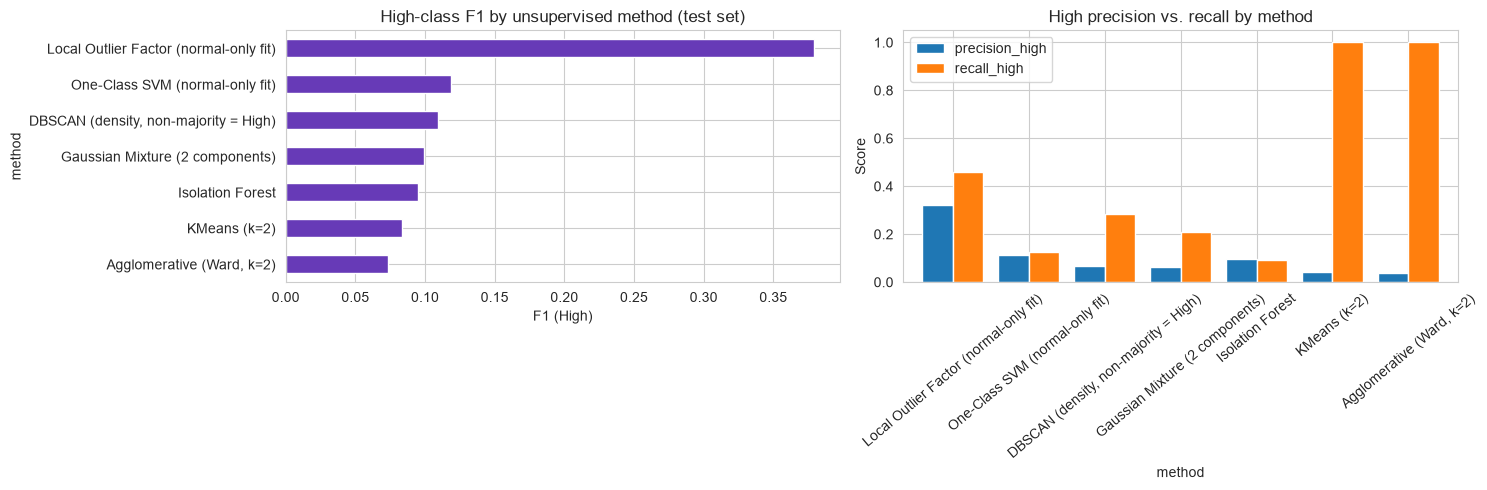


Best method by High-class F1: 'Local Outlier Factor (normal-only fit)' (F1=0.379, precision=0.322, recall=0.461)

For reference, the v7 supervised champion (SMOTE + tuned RF) scored roughly precision~0.7-0.8, recall~0.7-0.8 range on the same High class (see your v7 run's Section 9 output for the exact numbers) -- unsupervised methods are not expected to beat a model that was shown the labels, but this shows how close label-free detection can get on this feature set.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

unsupervised_df['f1_high'].sort_values().plot(kind='barh', ax=axes[0], color='#673AB7', edgecolor='white')
axes[0].set_title('High-class F1 by unsupervised method (test set)')
axes[0].set_xlabel('F1 (High)')

unsupervised_df[['precision_high', 'recall_high']].plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('High precision vs. recall by method')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('unsupervised_strategy_comparison_v8.png', dpi=150, bbox_inches='tight')
plt.show()

best_method_name = unsupervised_df['f1_high'].idxmax()
print(f"\nBest method by High-class F1: '{best_method_name}' "
      f"(F1={unsupervised_df.loc[best_method_name, 'f1_high']:.3f}, "
      f"precision={unsupervised_df.loc[best_method_name, 'precision_high']:.3f}, "
      f"recall={unsupervised_df.loc[best_method_name, 'recall_high']:.3f})")

print(f"\nFor reference, the v7 supervised champion (SMOTE + tuned RF) scored roughly precision~0.7-0.8, "
      f"recall~0.7-0.8 range on the same High class (see your v7 run's Section 9 output for the exact numbers) --"
      f" unsupervised methods are not expected to beat a model that was shown the labels, but this shows how "
      f"close label-free detection can get on this feature set.")

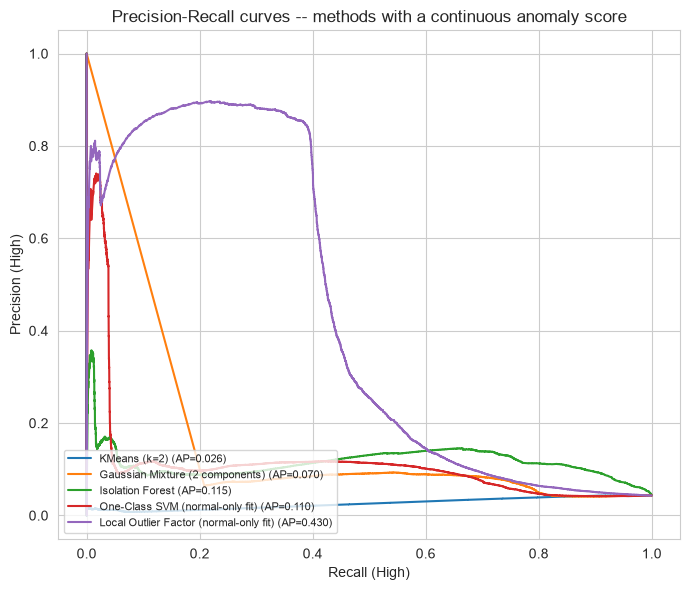

In [19]:
if unsupervised_scores:
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, score in unsupervised_scores.items():
        y_true_for_score = y_test if len(score) == len(y_test) else y_agg
        prec_arr, rec_arr, _ = precision_recall_curve(y_true_for_score, score)
        ap = average_precision_score(y_true_for_score, score)
        ax.plot(rec_arr, prec_arr, label=f'{name} (AP={ap:.3f})')
    ax.set_xlabel('Recall (High)')
    ax.set_ylabel('Precision (High)')
    ax.set_title('Precision-Recall curves -- methods with a continuous anomaly score')
    ax.legend(fontsize=8, loc='lower left')
    plt.tight_layout()
    plt.savefig('pr_curves_unsupervised_v8.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No continuous-score methods available to plot.")

---
# Section 8 — Visual Inspection: PCA Projection & Confusion Matrices

A 2D PCA projection of the scaled test features, colored first by the true label and then by the champion
method's predicted label, makes it easy to eyeball whether the disagreement is scattered noise or a specific,
explainable region (e.g. the same boundary-zone overlap v7's TEST CELL 4 found for `cpu_migrations` /
`runtime_per_switch`).

Explained variance (2 components): 0.323


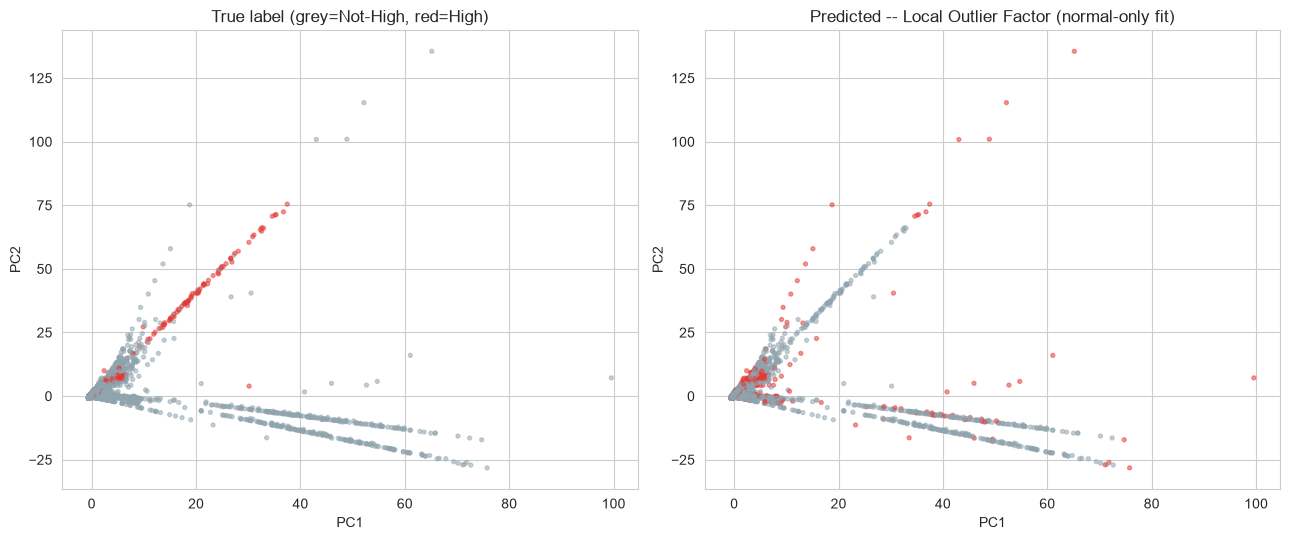

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test_scaled)   # fit on test here purely for visualization, not modeling
print(f"Explained variance (2 components): {pca.explained_variance_ratio_.sum():.3f}")

champion_pred_lookup = {
    'KMeans (k=2)': km_pred,
    'Gaussian Mixture (2 components)': gmm_pred,
    'Isolation Forest': iso_pred,
    'One-Class SVM (normal-only fit)': ocsvm_pred,
    'Local Outlier Factor (normal-only fit)': lof_pred,
}
# Agglomerative / DBSCAN ran on a (sub)sample of the test set, so they're excluded from this full-test PCA plot.

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test.map({0: '#90A4AE', 1: '#E53935'}),
                s=8, alpha=0.5)
axes[0].set_title('True label (grey=Not-High, red=High)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

if best_method_name in champion_pred_lookup:
    champ_pred_full = champion_pred_lookup[best_method_name]
    axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                     c=pd.Series(champ_pred_full, index=X_test_scaled.index).map({0: '#90A4AE', 1: '#E53935'}),
                     s=8, alpha=0.5)
    axes[1].set_title(f'Predicted -- {best_method_name}')
else:
    axes[1].set_title(f'{best_method_name} ran on a subsample -- see its own eval cell above for its confusion matrix')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('pca_projection_v8.png', dpi=150, bbox_inches='tight')
plt.show()

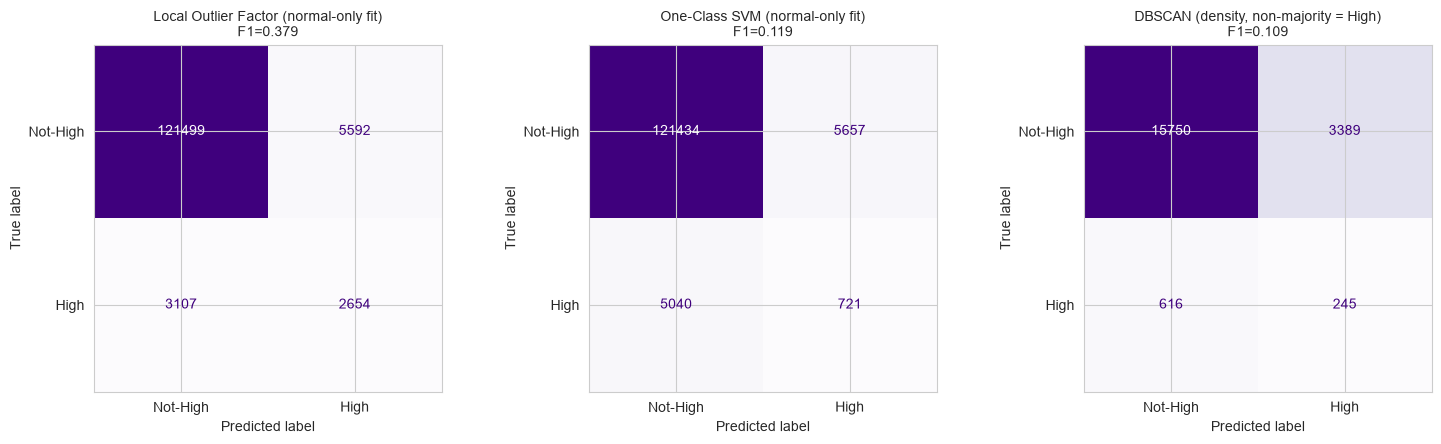

In [21]:
top_n = 3
top_methods = unsupervised_df.head(top_n).index.tolist()

fig, axes = plt.subplots(1, top_n, figsize=(5 * top_n, 4.5))
if top_n == 1:
    axes = [axes]

for ax, name in zip(axes, top_methods):
    cm = unsupervised_confusions[name]
    disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(f'{name}\nF1={unsupervised_df.loc[name, "f1_high"]:.3f}', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices_top3_v8.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 9 — Champion Selection & Artifact Saving

Same artifact-saving discipline as v7's Section 9, adapted for whichever object type the champion method
produces (a fitted estimator with `.predict()`, vs. a mapping dict for the transductive methods that have none).

In [22]:
fitted_models = {
    'KMeans (k=2)': kmeans,
    'Gaussian Mixture (2 components)': gmm,
    'Isolation Forest': iso_forest,
    'One-Class SVM (normal-only fit)': ocsvm,
    'Local Outlier Factor (normal-only fit)': lof,
}

print(f"Champion (unsupervised): '{best_method_name}'")
print(f"  High precision : {unsupervised_df.loc[best_method_name, 'precision_high']:.3f}")
print(f"  High recall    : {unsupervised_df.loc[best_method_name, 'recall_high']:.3f}")
print(f"  High F1        : {unsupervised_df.loc[best_method_name, 'f1_high']:.3f}")
print(f"  ARI / NMI      : {unsupervised_df.loc[best_method_name, 'ari']:.3f} / {unsupervised_df.loc[best_method_name, 'nmi']:.3f}")

if best_method_name in fitted_models:
    import joblib
    joblib.dump(fitted_models[best_method_name], 'champion_unsupervised_model_v8.pkl')
    joblib.dump(scaler, 'scaler_v8.pkl')
    print("\nSaved: champion_unsupervised_model_v8.pkl")
    print("Saved: scaler_v8.pkl  (required -- this model expects scaled input)")
else:
    print(f"\n'{best_method_name}' is transductive (no .predict) -- there is no reusable model object to save.")
    print("If you want to deploy it, either (a) refit it on every new batch, or (b) treat its output on this")
    print("run as a one-off diagnostic and deploy the next-best method from the table that does support .predict().")

with open('feature_cols_v8.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print("Saved: feature_cols_v8.json")

with open('label_threshold_v8.json', 'w') as f:
    json.dump({'high_threshold_ns': HIGH_THRESHOLD_NS, 'high_prevalence_train': HIGH_PREVALENCE_TRAIN}, f, indent=2)
print("Saved: label_threshold_v8.json")

unsupervised_df.to_csv('unsupervised_strategy_comparison_v8.csv')
print("Saved: unsupervised_strategy_comparison_v8.csv")

Champion (unsupervised): 'Local Outlier Factor (normal-only fit)'
  High precision : 0.322
  High recall    : 0.461
  High F1        : 0.379
  ARI / NMI      : 0.320 / 0.146

Saved: champion_unsupervised_model_v8.pkl
Saved: scaler_v8.pkl  (required -- this model expects scaled input)
Saved: feature_cols_v8.json
Saved: label_threshold_v8.json
Saved: unsupervised_strategy_comparison_v8.csv


## Summary

- **Same data foundation as v6/v7** (Section 1): identical loading, cleaning, feature engineering, and
  leakage-free `FEATURE_COLS` allowlist — nothing about *which columns are safe to use* changes between the
  supervised and unsupervised tracks.
- **Label used for evaluation only** (Section 2): `y` is computed the same way as v7's binary champion but is
  never passed to a `.fit()` call — the one exception (contamination/nu priors in Section 6) is a single
  aggregate prevalence number, called out explicitly where it's used.
- **Two families compared side by side** (Sections 4-6): partition clustering that generalizes to new rows
  (KMeans, GMM), transductive clustering that has to be refit on every new batch (Agglomerative, DBSCAN), and
  purpose-built anomaly/novelty detectors (Isolation Forest, One-Class SVM, LOF) — seven genuinely different
  algorithms, not seven hyperparameter variants of one.
- **Arbitrary cluster IDs handled explicitly** (`best_binary_alignment`): since clustering doesn't know which
  cluster is "High," both label mappings are tried and the better-aligned one kept, purely for scoring.
- **Comparable scoring to v7** (Section 7): High-class precision/recall/F1 as the headline metric, plus ARI/NMI
  as assumption-free label-agreement checks and PR/ROC-AUC wherever a continuous anomaly score exists.
- **Visual sanity check** (Section 8): PCA projection to eyeball whether disagreement with the true label is
  scattered or concentrated in a specific region, plus confusion matrices for the top 3 methods.

**How to read the result:** unsupervised methods have no access to the label, so a well-separated result here is
a stronger signal that `avg_stall_ns`-based severity is genuinely reflected in the *other* engineered features —
not just circularly recoverable because a supervised model was told the answer. A method landing far below the
v7 supervised numbers is expected; a method landing close to v7 is a meaningful finding about the feature set
itself, worth writing up separately from "which algorithm won."

**Next steps:** if the champion here is a partition-clustering method (KMeans/GMM), try re-running Section 4
with `k=3` and inspecting whether a natural third cluster maps onto the old Medium band from v6 — that would
suggest the binary collapse is hiding real structure the unsupervised method can still see even without labels.